In [253]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data.src import data_loader

from algo_regime.src import regime_detector 
import gmmhmm




# (1) Data Pipeline Overview

## Index Universe

We track **9 major stock indices** across three regions:

| Region   | Index          | Ticker  |
|----------|----------------|---------|
| America  | S&P 500        | ^GSPC   |
| America  | Dow Jones      | ^DJI    |
| America  | Nasdaq         | ^IXIC   |
| Europe   | FTSE 100       | ^FTSE   |
| Europe   | CAC 40         | ^FCHI   |
| Europe   | DAX            | ^GDAXI  |
| Asia     | KOSPI          | ^KS11   |
| Asia     | Nikkei 225     | ^N225   |
| Asia     | Hang Seng      | ^HSI    |

## Raw Data Structure

Each index is downloaded from Yahoo Finance with **daily OHLCV** columns:
```
Date | Open | High | Low | Close | Volume
```

After merging, the full DataFrame uses a **MultiIndex on columns**: `(index_name, OHLCV_field)`, so accessing S&P 500 closing prices looks like `df["SP500"]["Close"]`.

## Feature Engineering

From the closing prices, two families of features are computed:

**1. Log-returns** over multiple horizons (default: 1, 5, 21 trading days):

$$r_{t,p} = \ln\left(\frac{P_t}{P_{t-p}}\right)$$

**2. Rolling annualised volatility** (default windows: 21 and 63 days):

$$\sigma_{t,w} = \text{std}\left(r_{t-w:t}\right) \times \sqrt{252}$$

This produces a feature matrix of shape `(T, 9 × (3 returns + 2 vols)) = (T, 45)` columns, where each row is one trading day and each column is `(index_name, feature_name)`.

## Pipeline Summary
```
Yahoo Finance API
       │
       ▼
  Raw OHLCV (per index)
       │
       ▼
  Merged DataFrame (MultiIndex columns)
       │
       ▼
  Close prices only (simple DataFrame)
       │
       ├──► Log-returns (1d, 5d, 21d)
       │
       ├──► Rolling volatility (21d, 63d)
       │
       ▼
  Feature matrix → Clustering / PCA
```

In [478]:
start_date = '2006-01-01'
end_date = '2020-01-01'
interval = '1d'



## (1.1) America Data 

- Dow Jones Index
- S&P 500 Index
- NASDAQ Index 

In [479]:
df_america = data_loader.get_close_prices(start_date=start_date, end_date=end_date, regions=['america'], interval=interval)
df_america.head()
print(df_america.shape)

(3523, 3)


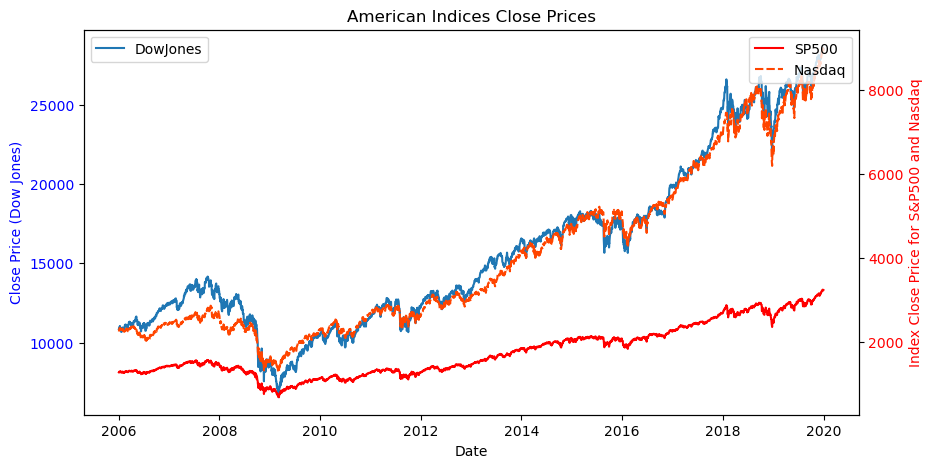

In [480]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=df_america.drop(columns=['SP500', 'Nasdaq']), ax=ax)
ax2 = ax.twinx()
sns.lineplot(data=df_america[['SP500', 'Nasdaq']], ax=ax2, palette=['red', 'orangered'])
ax2.set_ylabel('Index Close Price for S&P500 and Nasdaq', color='r')
ax2.tick_params(axis='y', labelcolor='r')
ax.set_title('American Indices Close Prices')
ax.set_xlabel('Date')
ax.set_ylabel('Close Price (Dow Jones)', color= 'b')
ax.tick_params(axis='y', labelcolor='b')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()

# (1.2) Asia Data 

- Nikkei 225
- Kospi 
- Hang Seng 

In [481]:
df_asia = data_loader.get_close_prices(start_date=start_date, end_date=end_date, regions=['asia'], interval=interval)
df_asia.head()
print(df_asia.shape)

(3635, 3)


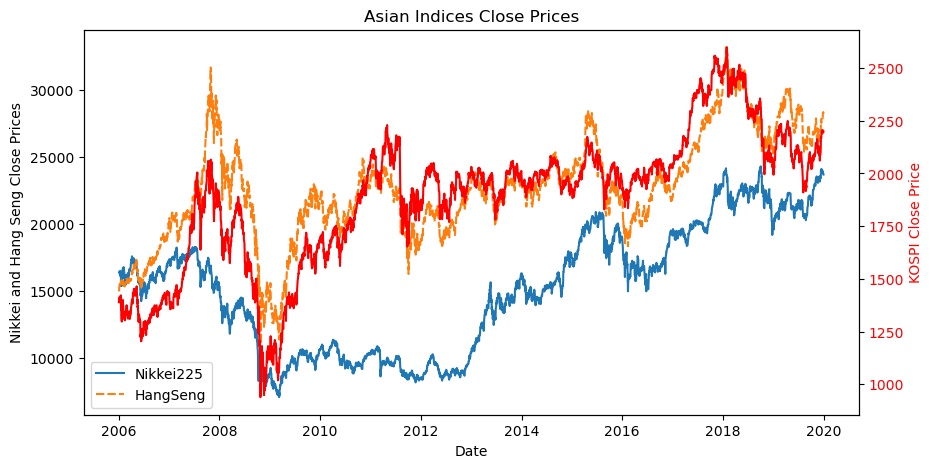

In [482]:
fig ,ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=df_asia.drop(columns=['KOSPI']), ax=ax)
ax.set_title('Asian Indices Close Prices')
#add a  different scale for the KOSPI index
ax2 = ax.twinx()
sns.lineplot(data=df_asia['KOSPI'], ax=ax2, color='r')
ax2.set_ylabel('KOSPI Close Price', color='r')
ax2.tick_params(axis='y', labelcolor='r')


ax.set_xlabel('Date')
ax.set_ylabel('Nikkei and Hang Seng Close Prices')
plt.show()

# (1.3) Europe Data 

- Cac 40
- DAX
- FTSE 100

In [483]:
df_europe = data_loader.get_close_prices(start_date=start_date, end_date=end_date, regions=['europe'], interval=interval)
df_europe.head()
print(df_europe.shape)

(3590, 3)


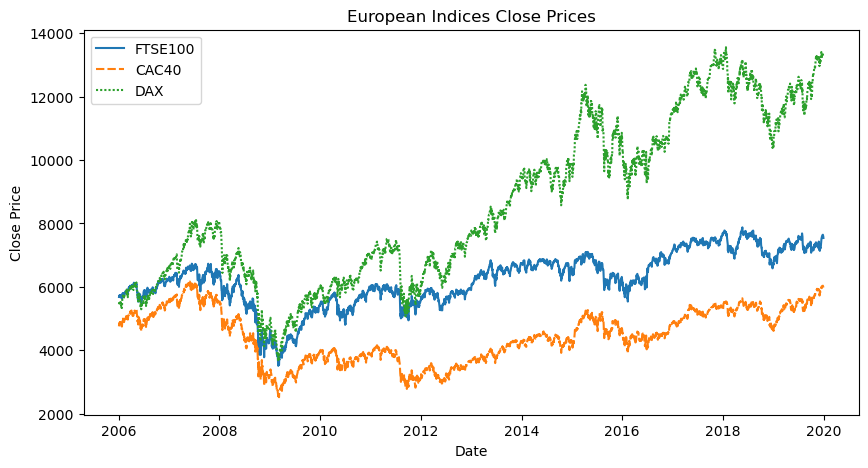

In [484]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_europe, ax=plt.gca())
plt.title('European Indices Close Prices')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()

# (2) K-means with PCA to detect regime  

## The Mathematics of K-Means Regime Detection

### Phase 1: Feature Engineering (State Encoding)

To transform sequential time-series data into cross-sectional features, we calculate several rolling metrics for each trading day $t$:

**1. Log Returns**
Ensures stationarity and additive symmetry over $p$ periods:
$$r_{t, p} = \ln\left(\frac{P_t}{P_{t-p}}\right)$$

**2. Annualized Rolling Volatility**
Measures dispersion over a rolling window $w$ (scaled to 252 trading days):
$$\sigma_{t, w} = \sqrt{252} \cdot \sqrt{\frac{1}{w-1} \sum_{i=0}^{w-1} \left(r_{t-i} - \mu_{w}\right)^2}$$

**3. Rolling Cross-Correlation (Pearson)**
Captures co-movement between indices $X$ and $Y$, which often spikes during regime shifts (e.g., market panics):
$$\rho_{X,Y, t} = \frac{\sum_{i=0}^{w-1} (r_{X, t-i} - \bar{r}_X)(r_{Y, t-i} - \bar{r}_Y)}{\sqrt{\sum_{i=0}^{w-1} (r_{X, t-i} - \bar{r}_X)^2 \sum_{i=0}^{w-1} (r_{Y, t-i} - \bar{r}_Y)^2}}$$

**4. Momentum Z-Score**
Measures mean-reversion by normalizing the distance between current price and a moving average:
$$Z_t = \frac{P_t - \mu_{\text{MA}}}{\sigma_{\text{lookback}}}$$

---

### Phase 2: Dimensionality Reduction

**1. Standardization**
Normalizes features so algorithms based on Euclidean distance do not overweight features with larger absolute bounds:
$$z_{t,j} = \frac{x_{t,j} - \mu_j}{\sigma_j}$$

**2. Principal Component Analysis (PCA)**
Addresses collinearity by projecting the matrix onto an orthogonal subspace. It solves for the eigenvectors $\mathbf{v}$ and eigenvalues $\lambda$ of the covariance matrix $\boldsymbol{\Sigma}$:
$$\boldsymbol{\Sigma} \mathbf{v} = \lambda \mathbf{v}$$

---

### Phase 3: K-Means Objective Function

K-Means seeks to partition the trading days into $K$ distinct regimes by minimizing the **Within-Cluster Sum of Squares (WCSS)**, or Inertia $J$. It minimizes the squared distance between each day's feature vector $\mathbf{x}_t$ and its assigned regime centroid $\boldsymbol{\mu}_k$:
$$J = \sum_{k=1}^{K} \sum_{\mathbf{x}_t \in S_k} \|\mathbf{x}_t - \boldsymbol{\mu}_k\|^2$$

---

### Phase 4: Optimal $K$-Selection

To rigorously determine the correct number of regimes, we calculate the **Silhouette Score** for each day $i$. This metric evaluates cohesion $a(i)$ (average distance to days in the same regime) versus separation $b(i)$ (average distance to days in the nearest different regime):
$$s(i) = \frac{b(i) - a(i)}{\max\{a(i), b(i)\}}$$
*A mean score closer to 1.0 indicates dense, well-separated regimes.*

## (2.1) Regime detection on American Indices 

In [547]:
from algo_regime.src import regime_detector
from algo_regime.src import metrics
import gmmhmm  
import importlib
importlib.reload(regime_detector)
importlib.reload(metrics)
rd_america = regime_detector.RegimeDetector(df_america, use_pca = True, n_regimes= None)
rd_america.fit()
regime_labels_ptt = rd_america.peak_to_trough_labelling(drawdown_threshold=-0.1)
skmeans_labels = rd_america.detect_regime_skmeans(N_S = 10, L = 100, h1 = 60, h2 = 12, epsilon = 1e-6)

Index(['SP500_ret_1d', 'DowJones_ret_1d', 'Nasdaq_ret_1d', 'SP500_ret_5d',
       'DowJones_ret_5d', 'Nasdaq_ret_5d', 'SP500_ret_21d', 'DowJones_ret_21d',
       'Nasdaq_ret_21d', 'SP500_vol_21d', 'DowJones_vol_21d', 'Nasdaq_vol_21d',
       'SP500_vol_63d', 'DowJones_vol_63d', 'Nasdaq_vol_63d',
       'corr_SP500_DowJones_63d', 'corr_SP500_Nasdaq_63d',
       'corr_DowJones_Nasdaq_63d', 'SP500_zscore_63d', 'DowJones_zscore_63d',
       'Nasdaq_zscore_63d', 'SP500_rsi_14d', 'DowJones_rsi_14d',
       'Nasdaq_rsi_14d'],
      dtype='str')
(3460, 24)
(3460, 7)
shape of feature_reduced: (3460, 7)
Fitting KMeans for k=2... with X shape (3460, 7)
Fitting KMeans for k=3... with X shape (3460, 7)
Fitting KMeans for k=4... with X shape (3460, 7)
Fitting KMeans for k=5... with X shape (3460, 7)
Fitting KMeans for k=6... with X shape (3460, 7)
Fitting KMeans for k=7... with X shape (3460, 7)
Fitting KMeans for k=8... with X shape (3460, 7)
(3460,)
shape of close: (3523, 3)
Simulation 1/10 comple

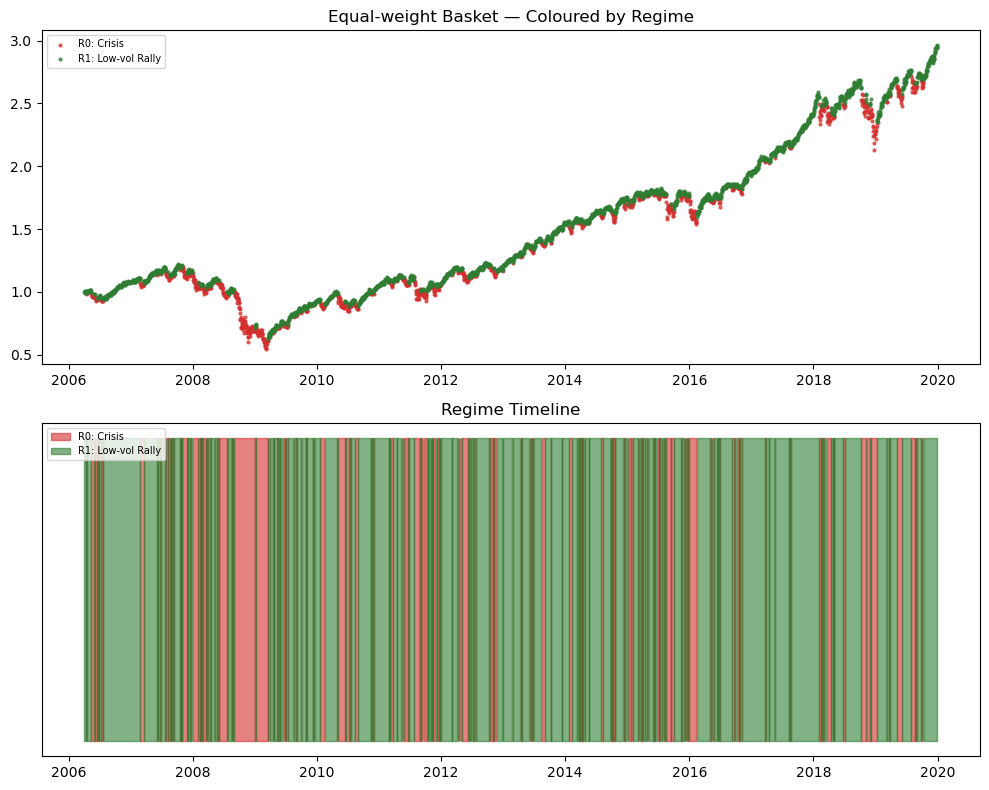

In [548]:
fig = rd_america.plot_regime_profile()
fig.savefig('graphs/regime_profile_america.png')


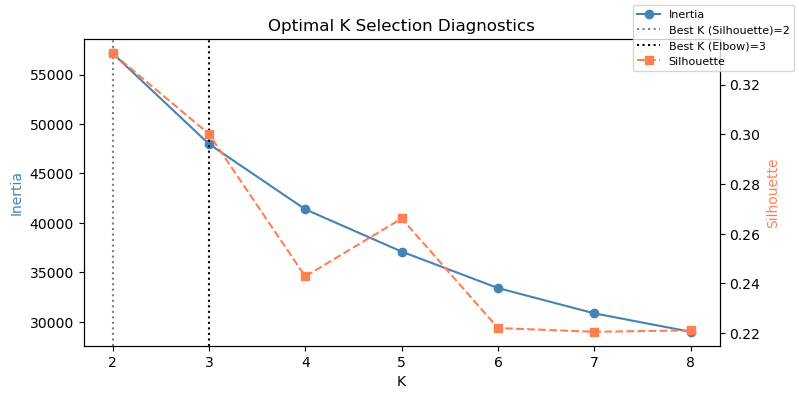

In [549]:
fig = rd_america.plot_k_selection()
fig.savefig('graphs/k_selection_america.png')


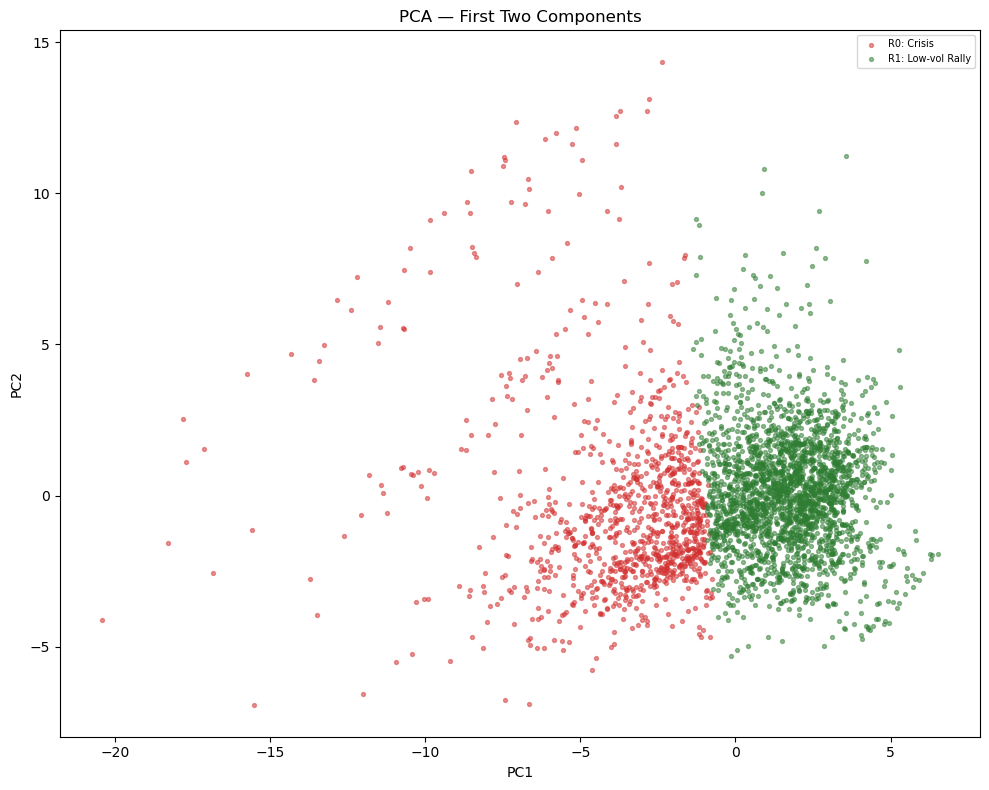

In [550]:
fig = rd_america.plot_cluster_pca()
fig.savefig('graphs/cluster_pca_america.png')

In [551]:
#Plot balanced accuracy score of the regime labels against the peak-to-trough labels
from sklearn.metrics import balanced_accuracy_score
balanced_acc = balanced_accuracy_score(rd_america.labels, rd_america.regime_labels_ptt)
print(f"Balanced Accuracy Score of Regime Labels vs Peak-to-Trough Labels: {balanced_acc:.4f}")

Balanced Accuracy Score of Regime Labels vs Peak-to-Trough Labels: 0.6124


Model comparison with HMM-GMM model 


In [563]:
import gmmhmm
import importlib
importlib.reload(gmmhmm)


<module 'gmmhmm' from '/Users/oscarpeyron/Downloads/003_ETUDE_POST_BAC/MASTER_UCL_COMP_FINANCE/T2/001_ML_Fin/Algorithmic-Trading-via-Regime-Detection-and-Stock-Grouping-/gmmhmm.py'>

In [564]:
hmm_america = gmmhmm.HMMRegimeDetector(df_america, n_regimes=2, use_pca=True)
hmm_america.fit()

bt_hmm_america = hmm_america.backtest(initial_capital=100)
print(bt_hmm_america.columns)


Index(['basket_ret', 'strategy_ret', 'cum_basket', 'cum_strategy',
       'sharpe_basket', 'sharpe_strategy', 'calmar_basket', 'calmar_strategy',
       'ann_vol_basket', 'ann_vol_strategy', 'ann_ret_basket',
       'ann_ret_strategy'],
      dtype='str')


In [565]:
bt_america = rd_america.backtest(initial_capital=100)
bt_america_skmeans = rd_america.backtest_skmeans(initial_capital=100)

shape of simple_ret: (3523,)


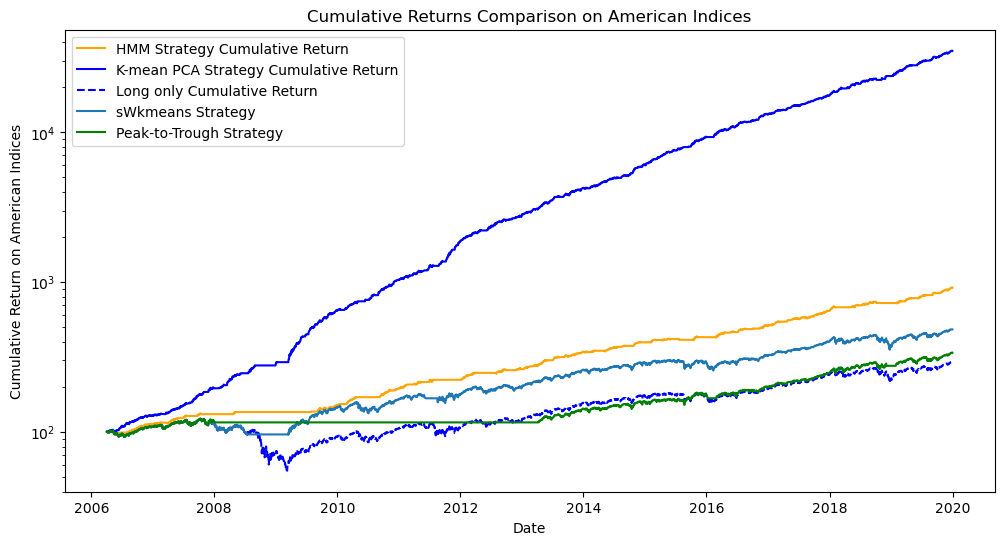

In [566]:
fig = plt.figure(figsize=(12, 6))


plt.plot(bt_hmm_america['cum_strategy'], label='HMM Strategy Cumulative Return', color='orange')
plt.plot(bt_america['cum_strategy'], label='K-mean PCA Strategy Cumulative Return', color='blue')
plt.plot(bt_america['cum_basket'], label='Long only Cumulative Return', color='blue', linestyle='--')
plt.plot(bt_america_skmeans.index, bt_america_skmeans['cum_strategy_skmeans'], label='sWkmeans Strategy')
plt.plot(bt_america["cum_strategy_ptt"], label='Peak-to-Trough Strategy',color='green')
plt.title('Cumulative Returns Comparison on American Indices')
plt.xlabel('Date')
plt.yscale('log')
plt.ylabel('Cumulative Return on American Indices')
plt.legend()
fig.savefig('graphs/cumulative_returns_comparison_america.png')

In [568]:
print("-- Backtest Summary --")
print('---------------------- PCA KMeans Strategy Performance ----------------------')
print(f"Final Cumulative Return : {bt_america['cum_strategy'].iloc[-1]:.2f}")
print(f"Sharpe Ratio : {bt_america['sharpe_strategy'].iloc[-1]:.2f}")
print(f'Calmar Ratio : {bt_america["calmar_strategy"].iloc[-1]:.2f}')
print(f'Annualized Return : {bt_america["ann_return_strategy"].iloc[-1]:.2f}')
print(f'Annualized Volatility : {bt_america["ann_vol_strategy"].iloc[-1]:.2f}')

print('---------------------- HMM Strategy Performance ----------------------')
print(f"Final Cumulative Return (HMM): {bt_hmm_america['cum_strategy'].iloc[-1]:.2f}")
print(f"Sharpe Ratio (HMM): {bt_hmm_america['sharpe_strategy'].iloc[-1]:.2f}") 
print(f'Calmar Ratio (HMM): {bt_hmm_america["calmar_strategy"].iloc[-1]:.2f}')
print(f'Annualized Return (HMM): {bt_hmm_america["ann_ret_strategy"].iloc[-1]:.2f}')
print(f'Annualized Volatility (HMM): {bt_hmm_america["ann_vol_strategy"].iloc[-1]:.2f}')

print('---------------------- sWkmeans Strategy Performance ----------------------')
print(f"Final Cumulative Return (sWkmeans): {bt_america_skmeans['cum_strategy_skmeans'].iloc[-1]:.2f}")
print(f"Sharpe Ratio (sWkmeans): {bt_america_skmeans['sharpe_strategy_skmeans'].iloc[-1]:.2f}")
print(f'Calmar Ratio (sWkmeans): {bt_america_skmeans["calmar_strategy_skmeans"].iloc[-1]:.2f}')
print(f'Annualized Return (sWkmeans): {bt_america_skmeans["ann_return_strategy_skmeans"].iloc[-1]:.2f}')
print(f'Annualized Volatility (sWkmeans): {bt_america_skmeans["ann_vol_strategy_skmeans"].iloc[-1]:.2f}')

print("---------------------- Peak-to-Trough Strategy Performance ----------------------")
print(f"Final Cumulative Return (PTT): {bt_america['cum_strategy_ptt'].iloc[-1]:.2f}")
print(f"Sharpe Ratio (PTT): {bt_america['sharpe_strategy_ptt'].iloc[-1]:.2f}")
print(f'Calmar Ratio (PTT): {bt_america["calmar_strategy_ptt"].iloc[-1]:.2f}')
print(f'Annualized Return (PTT): {bt_america["ann_return_strategy_ptt"].iloc[-1]:.2f}')
print(f'Annualized Volatility (PTT): {bt_america["ann_vol_strategy_ptt"].iloc[-1]:.2f}')

print('---------------------- Long Only Performance ----------------------')
print(f"Final Cumulative Return (Basket): {bt_america['cum_basket'].iloc[-1]:.2f}")
print(f"Sharpe Ratio (Basket): {bt_america['sharpe_basket'].iloc[-1]:.2f}") 
print(f'Calmar Ratio (Basket): {bt_america["calmar_basket"].iloc[-1]:.2f}')
print(f'Annualized Return (Basket): {bt_america["ann_return_basket"].iloc[-1]:.2f}')
print(f'Annualized Volatility (Basket): {bt_america["ann_vol_basket"].iloc[-1]:.2f}')


-- Backtest Summary --
---------------------- PCA KMeans Strategy Performance ----------------------
Final Cumulative Return : 34808.39
Sharpe Ratio : 4.37
Calmar Ratio : inf
Annualized Return : 0.53
Annualized Volatility : 0.10
---------------------- HMM Strategy Performance ----------------------
Final Cumulative Return (HMM): 915.48
Sharpe Ratio (HMM): 2.74
Calmar Ratio (HMM): 7.22
Annualized Return (HMM): 0.16
Annualized Volatility (HMM): 0.06
---------------------- sWkmeans Strategy Performance ----------------------
Final Cumulative Return (sWkmeans): 483.31
Sharpe Ratio (sWkmeans): 0.85
Calmar Ratio (sWkmeans): inf
Annualized Return (sWkmeans): 0.12
Annualized Volatility (sWkmeans): 0.15
---------------------- Peak-to-Trough Strategy Performance ----------------------
Final Cumulative Return (PTT): 337.18
Sharpe Ratio (PTT): 0.95
Calmar Ratio (PTT): inf
Annualized Return (PTT): 0.09
Annualized Volatility (PTT): 0.10
---------------------- Long Only Performance ------------------

## (2.2) Regime Detection on European Indices 

In [569]:
from algo_regime.src import regime_detector 
import importlib
importlib.reload(regime_detector)
df_europe.dropna(inplace=True)
print(df_europe.head())
rd_europe= regime_detector.RegimeDetector(df_europe, use_pca = True)
rd_europe.fit()
regime_labels_ptt = rd_europe.peak_to_trough_labelling(drawdown_threshold=-0.1)
skmeans_labels = rd_europe.detect_regime_skmeans(N_S = 10, L = 100, h1 = 10, h2 = 7, epsilon = 1e-6)

                FTSE100        CAC40          DAX
Date                                             
2006-01-03  5681.500000  4776.979980  5460.680176
2006-01-04  5714.600098  4838.520020  5523.620117
2006-01-05  5691.200195  4835.089844  5516.529785
2006-01-06  5731.799805  4867.149902  5536.319824
2006-01-09  5731.500000  4875.089844  5537.109863
Index(['FTSE100_ret_1d', 'CAC40_ret_1d', 'DAX_ret_1d', 'FTSE100_ret_5d',
       'CAC40_ret_5d', 'DAX_ret_5d', 'FTSE100_ret_21d', 'CAC40_ret_21d',
       'DAX_ret_21d', 'FTSE100_vol_21d', 'CAC40_vol_21d', 'DAX_vol_21d',
       'FTSE100_vol_63d', 'CAC40_vol_63d', 'DAX_vol_63d',
       'corr_FTSE100_CAC40_63d', 'corr_FTSE100_DAX_63d', 'corr_CAC40_DAX_63d',
       'FTSE100_zscore_63d', 'CAC40_zscore_63d', 'DAX_zscore_63d',
       'FTSE100_rsi_14d', 'CAC40_rsi_14d', 'DAX_rsi_14d'],
      dtype='str')
(3523, 24)
(3523, 10)
shape of feature_reduced: (3523, 10)
Fitting KMeans for k=2... with X shape (3523, 10)
Fitting KMeans for k=3... with X shape (

### Elbow Plot

Index(['FTSE100_ret_1d', 'CAC40_ret_1d', 'DAX_ret_1d', 'FTSE100_ret_5d',
       'CAC40_ret_5d', 'DAX_ret_5d', 'FTSE100_ret_21d', 'CAC40_ret_21d',
       'DAX_ret_21d', 'FTSE100_vol_21d', 'CAC40_vol_21d', 'DAX_vol_21d',
       'FTSE100_vol_63d', 'CAC40_vol_63d', 'DAX_vol_63d',
       'corr_FTSE100_CAC40_63d', 'corr_FTSE100_DAX_63d', 'corr_CAC40_DAX_63d',
       'FTSE100_zscore_63d', 'CAC40_zscore_63d', 'DAX_zscore_63d',
       'FTSE100_rsi_14d', 'CAC40_rsi_14d', 'DAX_rsi_14d'],
      dtype='str')
(3523, 24)
(3523, 10)
shape of feature_reduced: (3523, 10)
(3523,)


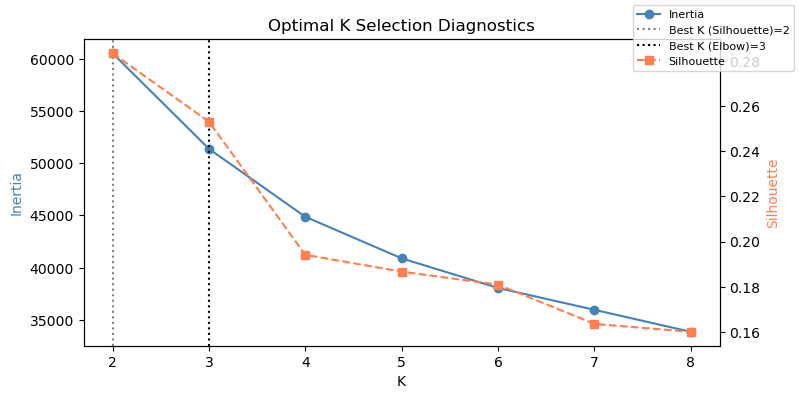

In [570]:
rd_europe.fit()
fig = rd_europe.plot_k_selection()
fig.savefig('graphs/k_selection_europe.png')

### Regime Prediction 

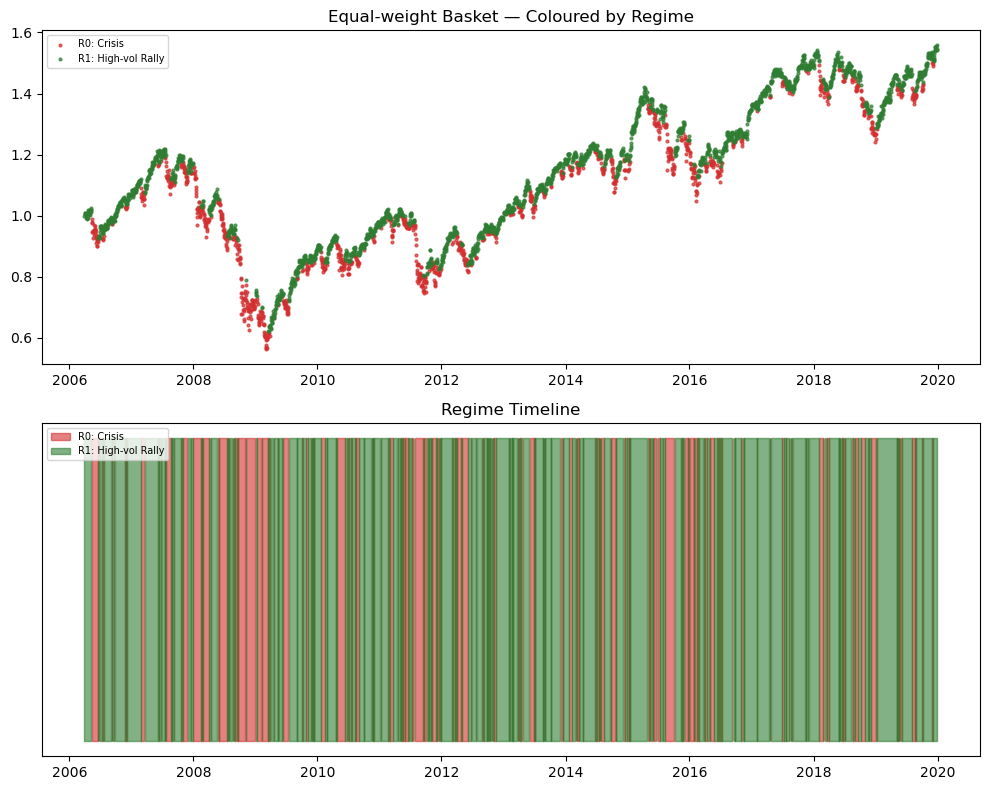

In [571]:
fig = rd_europe.plot_regime_profile()
fig.savefig('graphs/regime_profile_europe.png')

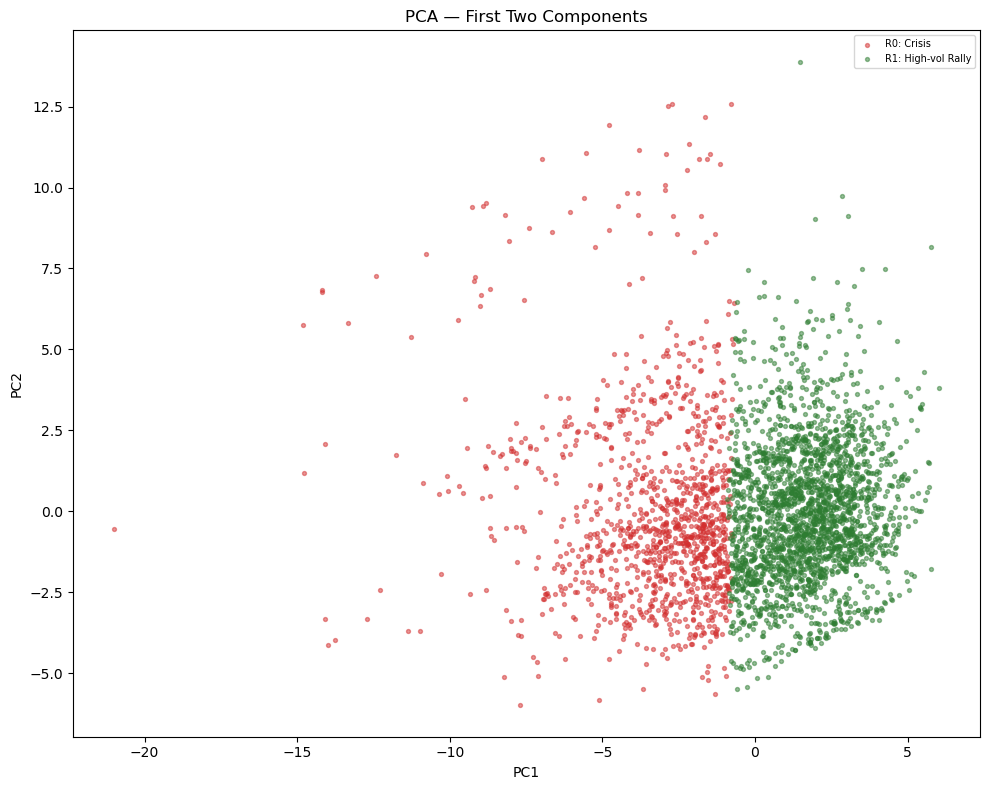

In [572]:
fig = rd_europe.plot_cluster_pca()
fig.savefig('graphs/cluster_pca_europe.png')

## Plot Backtest 

In [573]:
bt_hmm = gmmhmm.HMMRegimeDetector(df_europe, n_regimes=2, use_pca=True)
bt_hmm.fit()
bt_hmm_europe = bt_hmm.backtest(initial_capital=100)

In [574]:
from algo_regime.src import regime_detector 
importlib.reload(regime_detector)

bt_europe = rd_europe.backtest(initial_capital=100)
bt_europe_skmeans = rd_europe.backtest_skmeans(initial_capital=100)

shape of simple_ret: (3589,)


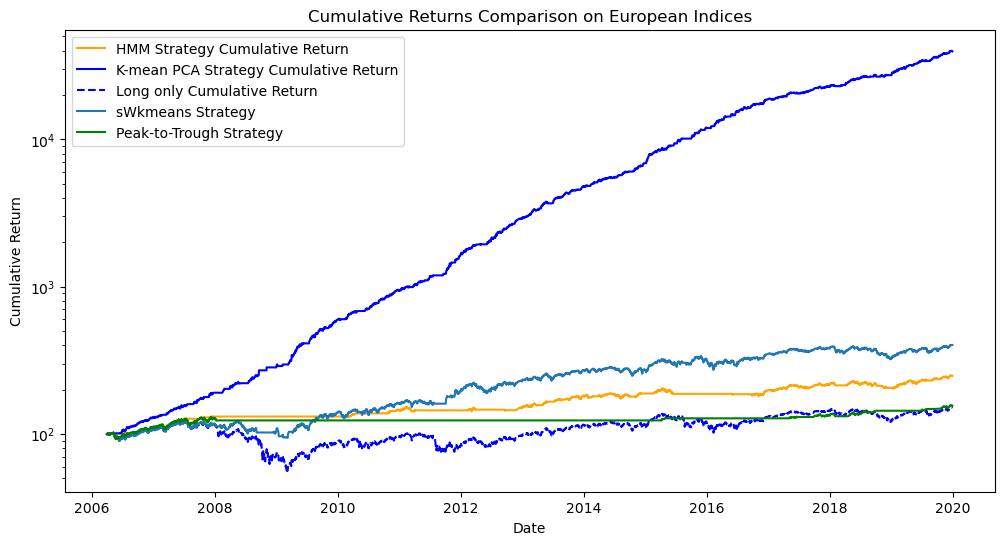

In [575]:
fig = plt.figure(figsize=(12, 6))
plt.plot(bt_hmm_europe['cum_strategy'], label='HMM Strategy Cumulative Return', color='orange')
plt.plot(bt_europe['cum_strategy'], label='K-mean PCA Strategy Cumulative Return', color='blue')
plt.plot(bt_europe['cum_basket'], label='Long only Cumulative Return', color='blue', linestyle='--')
plt.plot(bt_europe_skmeans['cum_strategy_skmeans'], label='sWkmeans Strategy')
plt.plot(bt_europe["cum_strategy_ptt"], label='Peak-to-Trough Strategy',color='green')
plt.title('Cumulative Returns Comparison on European Indices')
plt.xlabel('Date')
plt.yscale('log')
plt.ylabel('Cumulative Return')
plt.legend()
fig.savefig('graphs/cumulative_returns_comparison_europe.png')

In [578]:
print("-- Backtest Summary --")
print('---------------------- PCA KMeans Strategy Performance ----------------------')
print(f"Final Cumulative Return : {bt_europe['cum_strategy'].iloc[-1]:.2f}")
print(f"Sharpe Ratio : {bt_europe['sharpe_strategy'].iloc[-1]:.2f}")
print(f'Calmar Ratio : {bt_europe["calmar_strategy"].iloc[-1]:.2f}')
print(f'Annualized Return : {bt_europe["ann_return_strategy"].iloc[-1]:.2f}')
print(f'Annualized Volatility : {bt_europe["ann_vol_strategy"].iloc[-1]:.2f}')

print('---------------------- HMM Strategy Performance ----------------------')
print(f"Final Cumulative Return (HMM): {bt_hmm_europe['cum_strategy'].iloc[-1]:.2f}")
print(f"Sharpe Ratio (HMM): {bt_hmm_europe['sharpe_strategy'].iloc[-1]:.2f}") 
print(f'Calmar Ratio (HMM): {bt_hmm_europe["calmar_strategy"].iloc[-1]:.2f}')
print(f'Annualized Return (HMM): {bt_hmm_europe["ann_ret_strategy"].iloc[-1]:.2f}')
print(f'Annualized Volatility (HMM): {bt_hmm_europe["ann_vol_strategy"].iloc[-1]:.2f}')

print('---------------------- sWkmeans Strategy Performance ----------------------')
print(f"Final Cumulative Return (sWkmeans): {bt_europe_skmeans['cum_strategy_skmeans'].iloc[-1]:.2f}")
print(f"Sharpe Ratio (sWkmeans): {bt_europe_skmeans['sharpe_strategy_skmeans'].iloc[-1]:.2f}")
print(f'Calmar Ratio (sWkmeans): {bt_europe_skmeans["calmar_strategy_skmeans"].iloc[-1]:.2f}')
print(f'Annualized Return (sWkmeans): {bt_europe_skmeans["ann_return_strategy_skmeans"].iloc[-1]:.2f}')
print(f'Annualized Volatility (sWkmeans): {bt_europe_skmeans["ann_vol_strategy_skmeans"].iloc[-1]:.2f}')

print("---------------------- Peak-to-Trough Strategy Performance ----------------------")
print(f"Final Cumulative Return (PTT): {bt_europe['cum_strategy_ptt'].iloc[-1]:.2f}")
print(f"Sharpe Ratio (PTT): {bt_europe['sharpe_strategy_ptt'].iloc[-1]:.2f}")
print(f'Calmar Ratio (PTT): {bt_europe["calmar_strategy_ptt"].iloc[-1]:.2f}')
print(f'Annualized Return (PTT): {bt_europe["ann_return_strategy_ptt"].iloc[-1]:.2f}')
print(f'Annualized Volatility (PTT): {bt_europe["ann_vol_strategy_ptt"].iloc[-1]:.2f}')

print('---------------------- Long Only Performance ----------------------')
print(f"Final Cumulative Return (Basket): {bt_europe['cum_basket'].iloc[-1]:.2f}")
print(f"Sharpe Ratio (Basket): {bt_europe['sharpe_basket'].iloc[-1]:.2f}") 
print(f'Calmar Ratio (Basket): {bt_europe["calmar_basket"].iloc[-1]:.2f}')
print(f'Annualized Return (Basket): {bt_europe["ann_return_basket"].iloc[-1]:.2f}')
print(f'Annualized Volatility (Basket): {bt_europe["ann_vol_basket"].iloc[-1]:.2f}')


-- Backtest Summary --
---------------------- PCA KMeans Strategy Performance ----------------------
Final Cumulative Return : 39532.73
Sharpe Ratio : 3.91
Calmar Ratio : inf
Annualized Return : 0.53
Annualized Volatility : 0.11
---------------------- HMM Strategy Performance ----------------------
Final Cumulative Return (HMM): 247.17
Sharpe Ratio (HMM): 0.94
Calmar Ratio (HMM): 0.64
Annualized Return (HMM): 0.07
Annualized Volatility (HMM): 0.07
---------------------- sWkmeans Strategy Performance ----------------------
Final Cumulative Return (sWkmeans): 401.41
Sharpe Ratio (sWkmeans): 0.72
Calmar Ratio (sWkmeans): inf
Annualized Return (sWkmeans): 0.10
Annualized Volatility (sWkmeans): 0.15
---------------------- Peak-to-Trough Strategy Performance ----------------------
Final Cumulative Return (PTT): 155.08
Sharpe Ratio (PTT): 0.57
Calmar Ratio (PTT): inf
Annualized Return (PTT): 0.03
Annualized Volatility (PTT): 0.06
---------------------- Long Only Performance ------------------

## (2.3) Regime detection on Asian Indices 

In [579]:
from algo_regime.src import regime_detector 
import importlib
importlib.reload(regime_detector)
df_asia.dropna(inplace=True)
print(df_asia.head())
rd_asia= regime_detector.RegimeDetector(df_asia, use_pca = True)
rd_asia.fit()
regime_labels_ptt = rd_asia.peak_to_trough_labelling(drawdown_threshold=-0.1)
skmeans_labels = rd_asia.detect_regime_skmeans(N_S = 10, L = 100, h1 = 10, h2 = 7, epsilon = 1e-6)

                  KOSPI     Nikkei225      HangSeng
Date                                               
2006-01-04  1402.109985  16361.540039  15200.059570
2006-01-05  1395.510010  16425.369141  15271.129883
2006-01-06  1412.780029  16428.210938  15344.440430
2006-01-09  1408.329956  16428.210938  15547.429688
2006-01-10  1396.290039  16124.349609  15569.910156
Index(['KOSPI_ret_1d', 'Nikkei225_ret_1d', 'HangSeng_ret_1d', 'KOSPI_ret_5d',
       'Nikkei225_ret_5d', 'HangSeng_ret_5d', 'KOSPI_ret_21d',
       'Nikkei225_ret_21d', 'HangSeng_ret_21d', 'KOSPI_vol_21d',
       'Nikkei225_vol_21d', 'HangSeng_vol_21d', 'KOSPI_vol_63d',
       'Nikkei225_vol_63d', 'HangSeng_vol_63d', 'corr_KOSPI_Nikkei225_63d',
       'corr_KOSPI_HangSeng_63d', 'corr_Nikkei225_HangSeng_63d',
       'KOSPI_zscore_63d', 'Nikkei225_zscore_63d', 'HangSeng_zscore_63d',
       'KOSPI_rsi_14d', 'Nikkei225_rsi_14d', 'HangSeng_rsi_14d'],
      dtype='str')
(3561, 24)
(3561, 14)
shape of feature_reduced: (3561, 14)
Fittin

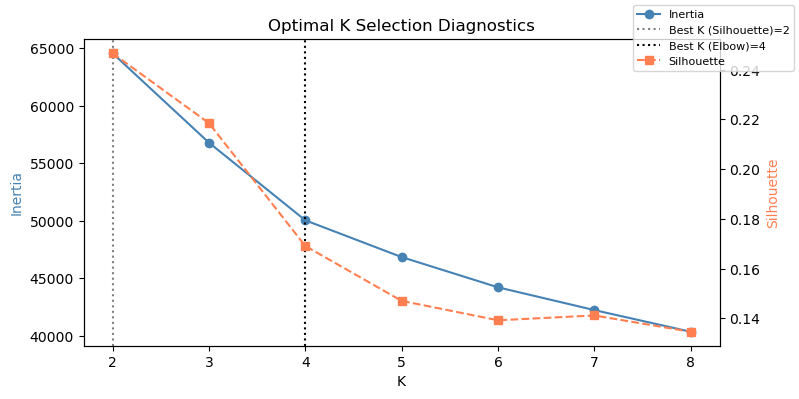

In [580]:
fig = rd_asia.plot_k_selection()
fig.savefig('graphs/k_selection_asia.png')

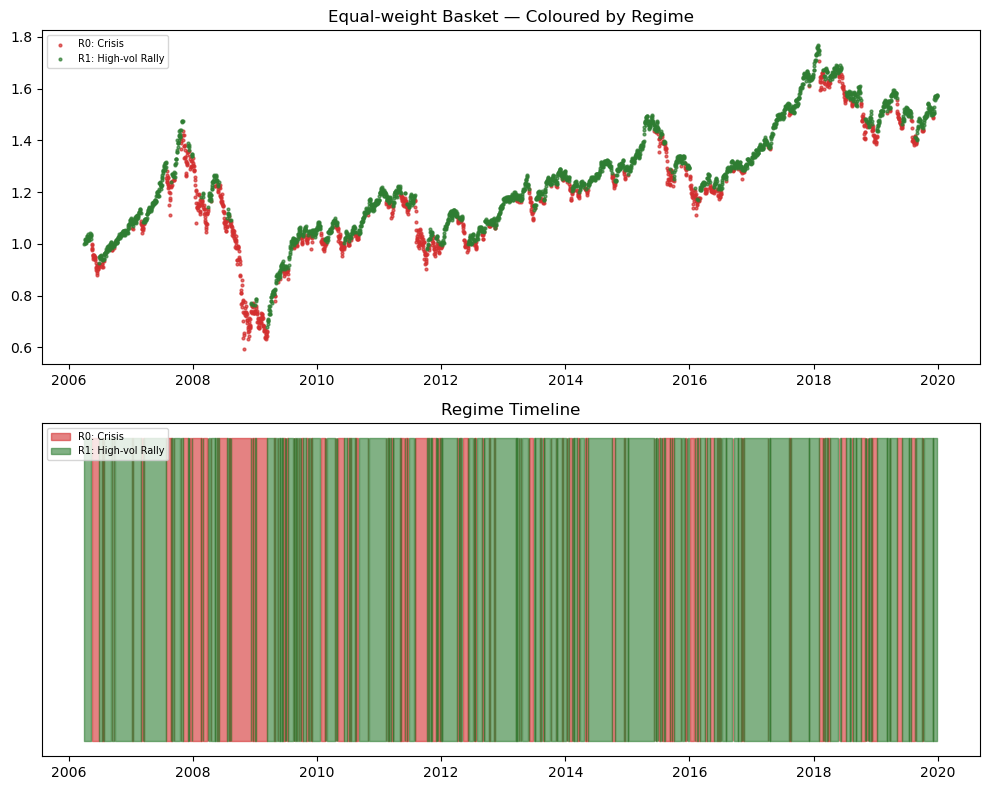

In [581]:
fig =rd_asia.plot_regime_profile()
fig.savefig('graphs/regime_profile_asia.png')

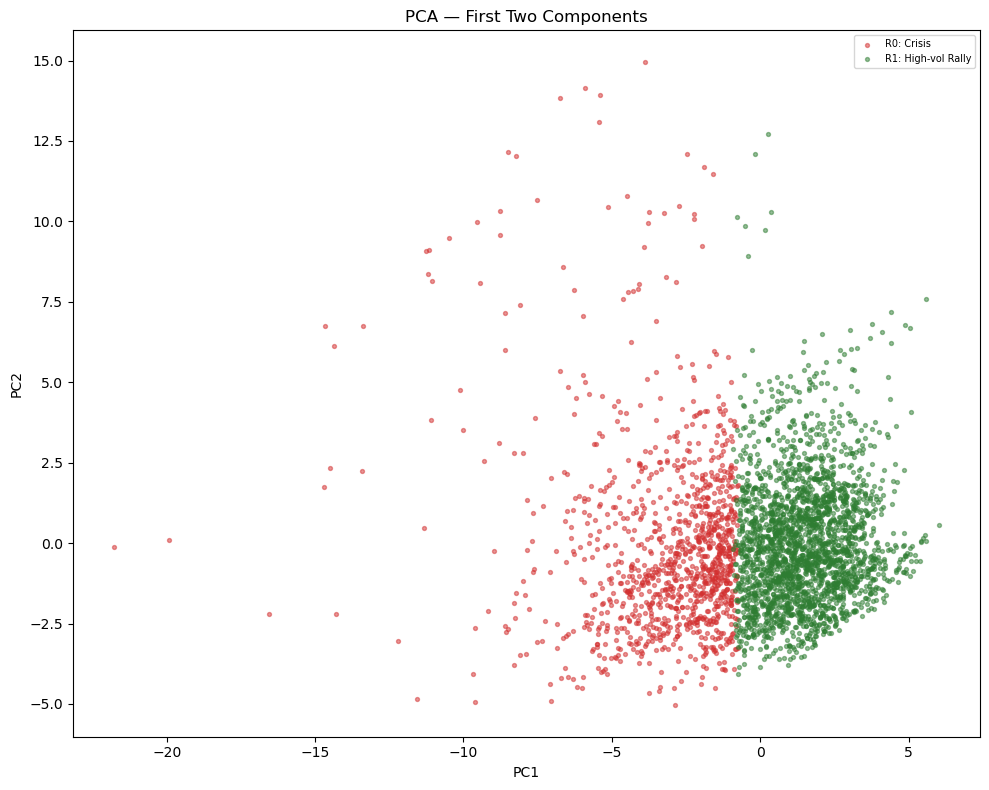

In [582]:
fig = rd_asia.plot_cluster_pca()
fig.savefig('graphs/cluster_pca_asia.png')

## Plot Backtest

In [583]:
bt_asia = rd_asia.backtest(initial_capital=100)
bt_asia_skmeans = rd_asia.backtest_skmeans(initial_capital=100)
hmm_asia = gmmhmm.HMMRegimeDetector(df_asia, n_regimes=2, use_pca=True)
hmm_asia.fit()
bt_hmm_asia = hmm_asia.backtest(initial_capital=100)


shape of simple_ret: (3633,)


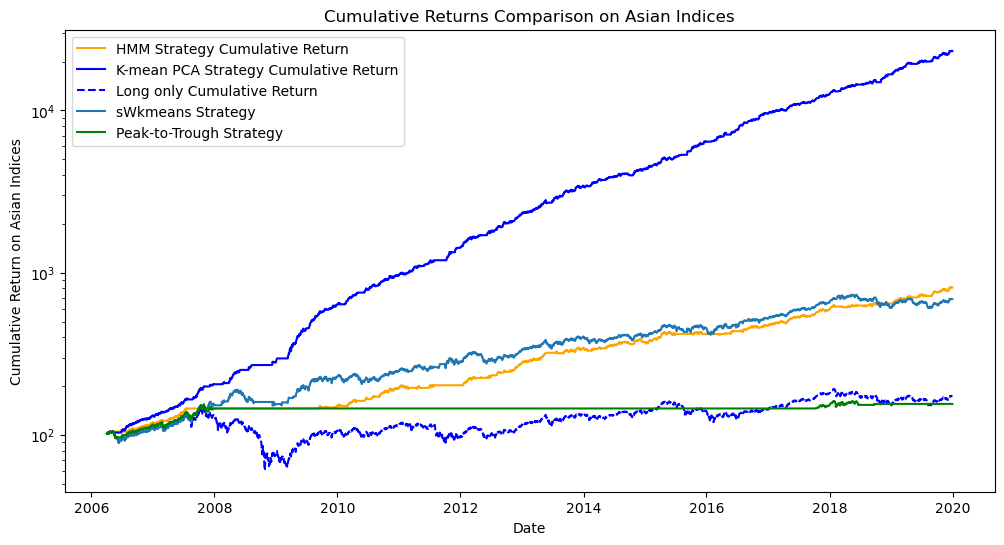

In [584]:
fig= plt.figure(figsize=(12, 6))
plt.plot(bt_hmm_asia['cum_strategy'], label='HMM Strategy Cumulative Return', color='orange')
plt.plot(bt_asia['cum_strategy'], label='K-mean PCA Strategy Cumulative Return', color='blue')
plt.plot(bt_asia['cum_basket'], label='Long only Cumulative Return', color='blue', linestyle='--')
plt.plot(bt_asia_skmeans['cum_strategy_skmeans'], label='sWkmeans Strategy')
plt.plot(bt_asia["cum_strategy_ptt"], label='Peak-to-Trough Strategy',color='green')
plt.title('Cumulative Returns Comparison on Asian Indices')
plt.xlabel('Date')
plt.yscale('log')
plt.ylabel('Cumulative Return on Asian Indices')
plt.legend()
fig.savefig('graphs/cumulative_returns_comparison_asia.png')

In [586]:
print("-- Backtest Summary --")
print('---------------------- PCA KMeans Strategy Performance ----------------------')
print(f"Final Cumulative Return : {bt_asia['cum_strategy'].iloc[-1]:.2f}")
print(f"Sharpe Ratio : {bt_asia['sharpe_strategy'].iloc[-1]:.2f}")
print(f'Calmar Ratio : {bt_asia["calmar_strategy"].iloc[-1]:.2f}')
print(f'Annualized Return : {bt_asia["ann_return_strategy"].iloc[-1]:.2f}')
print(f'Annualized Volatility : {bt_asia["ann_vol_strategy"].iloc[-1]:.2f}')

print('---------------------- HMM Strategy Performance ----------------------')
print(f"Final Cumulative Return (HMM): {bt_hmm_asia['cum_strategy'].iloc[-1]:.2f}")
print(f"Sharpe Ratio (HMM): {bt_hmm_asia['sharpe_strategy'].iloc[-1]:.2f}") 
print(f'Calmar Ratio (HMM): {bt_hmm_asia["calmar_strategy"].iloc[-1]:.2f}')
print(f'Annualized Return (HMM): {bt_hmm_asia["ann_ret_strategy"].iloc[-1]:.2f}')
print(f'Annualized Volatility (HMM): {bt_hmm_asia["ann_vol_strategy"].iloc[-1]:.2f}')

print('---------------------- sWkmeans Strategy Performance ----------------------')
print(f"Final Cumulative Return (sWkmeans): {bt_asia_skmeans['cum_strategy_skmeans'].iloc[-1]:.2f}")
print(f"Sharpe Ratio (sWkmeans): {bt_asia_skmeans['sharpe_strategy_skmeans'].iloc[-1]:.2f}")
print(f'Calmar Ratio (sWkmeans): {bt_asia_skmeans["calmar_strategy_skmeans"].iloc[-1]:.2f}')
print(f'Annualized Return (sWkmeans): {bt_asia_skmeans["ann_return_strategy_skmeans"].iloc[-1]:.2f}')
print(f'Annualized Volatility (sWkmeans): {bt_asia_skmeans["ann_vol_strategy_skmeans"].iloc[-1]:.2f}')

print("---------------------- Peak-to-Trough Strategy Performance ----------------------")
print(f"Final Cumulative Return (PTT): {bt_asia['cum_strategy_ptt'].iloc[-1]:.2f}")
print(f"Sharpe Ratio (PTT): {bt_asia['sharpe_strategy_ptt'].iloc[-1]:.2f}")
print(f'Calmar Ratio (PTT): {bt_asia["calmar_strategy_ptt"].iloc[-1]:.2f}')
print(f'Annualized Return (PTT): {bt_asia["ann_return_strategy_ptt"].iloc[-1]:.2f}')
print(f'Annualized Volatility (PTT): {bt_asia["ann_vol_strategy_ptt"].iloc[-1]:.2f}')

print('---------------------- Long Only Performance ----------------------')
print(f"Final Cumulative Return (Basket): {bt_asia['cum_basket'].iloc[-1]:.2f}")
print(f"Sharpe Ratio (Basket): {bt_asia['sharpe_basket'].iloc[-1]:.2f}") 
print(f'Calmar Ratio (Basket): {bt_asia["calmar_basket"].iloc[-1]:.2f}')
print(f'Annualized Return (Basket): {bt_asia["ann_return_basket"].iloc[-1]:.2f}')
print(f'Annualized Volatility (Basket): {bt_asia["ann_vol_basket"].iloc[-1]:.2f}')


-- Backtest Summary --
---------------------- PCA KMeans Strategy Performance ----------------------
Final Cumulative Return : 23225.90
Sharpe Ratio : 3.76
Calmar Ratio : inf
Annualized Return : 0.47
Annualized Volatility : 0.10
---------------------- HMM Strategy Performance ----------------------
Final Cumulative Return (HMM): 810.79
Sharpe Ratio (HMM): 1.90
Calmar Ratio (HMM): 4.30
Annualized Return (HMM): 0.15
Annualized Volatility (HMM): 0.08
---------------------- sWkmeans Strategy Performance ----------------------
Final Cumulative Return (sWkmeans): 687.00
Sharpe Ratio (sWkmeans): 1.04
Calmar Ratio (sWkmeans): inf
Annualized Return (sWkmeans): 0.15
Annualized Volatility (sWkmeans): 0.14
---------------------- Peak-to-Trough Strategy Performance ----------------------
Final Cumulative Return (PTT): 155.36
Sharpe Ratio (PTT): 0.54
Calmar Ratio (PTT): inf
Annualized Return (PTT): 0.03
Annualized Volatility (PTT): 0.06
---------------------- Long Only Performance ------------------

# (3) Hyperparameter tuning for the K-Mean Regime Detection Algorithm 